In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
#setup
#code
name = 'AAPL'
ticker = yf.Ticker(name) #import data
aapl_df = ticker.history(period="5y") #get data from 5 year period in dataframe
aapl_df.drop(['High','Close','Volume','Dividends','Stock Splits'], axis=1, inplace=True) #only have two columns, not seven
open = np.empty(shape = (1259), dtype = float)
close = np.empty(shape = (1259), dtype = float)

open=aapl_df[['Open']].to_numpy()

#when training ml model you have a set of steps, and you have to specify those steps

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
import sklearn

## **STEPS**
1. Get a dataset
2. Clean the data
3. Split the dataset (into train, test, validation) train the dataset on the training dataset, validate it and test it on the testing dataset to see how well the model handles unseen data (or else, the model will overfit to the training data)
4. Choose your model (which models you will use: like linear regression, random forests, decision trees, neural networks) how to combine and explain the models (about the parameters and the evaluation of this part)
5. Use MAE/MSE to evaluate models (MAE is mean absolute error, mean of the absolute values of the differences between predicted and actual. MSE is mean square error, the mean of the squared deviations from your predicted value and the actual value)

In [3]:
aapl_df.head()

,Open,Low
Date,,
2021-03-22 00:00:00-04:00,117.200889,117.132709
2021-03-23 00:00:00-04:00,120.122889,118.963832
2021-03-24 00:00:00-04:00,119.626160,116.947671
2021-03-25 00:00:00-04:00,116.431426,115.905468
2021-03-26 00:00:00-04:00,117.220362,115.827548


In [4]:
#opening prices for each day over the past 5 years
open

array([[117.2008885 ],
       [120.12288918],
       [119.62615953],
       ...,
       [252.63000488],
       [249.3999939 ],
       [248.11000061]])

In [5]:
X = np.zeros((1260,3))
Y = [0]*1260
#sliding window with a fixed window of 3 days, x is the 3 days, y is the next day outside the window (our prediction)
for i in range(1250):
  X[i] = [open[i][0],open[i+1][0],open[i+2][0]]
  Y[i] = open[i+3][0]

#gives you 3 consecutive days as input and the next day as output
print(X[0], Y[0])

[117.2008885  120.12288918 119.62615953] 116.43142597838931


In [6]:
#next step: check for empty values/discrepancies in the dataset
#then split dataset
from sklearn import linear_model

#shuffle so that we won't be biased and we want the general pattern of the last 5 years
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle = False) #no shuffling

#standard scaler

'''
scaler = sklearn.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit(X_test)
print(X_train.shape)'''

'\nscaler = sklearn.preprocessing.StandardScaler()\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.fit(X_test)\nprint(X_train.shape)'

In [7]:
lin_regr = linear_model.LinearRegression()
#.fit trains model
lin_regr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
lin_regr.coef_
#weights * day 1 + weights*day 2 + weights*day 3 = prediction

array([ 0.01139928, -0.00283284,  0.98733736])

Linear Regression

In [9]:
from sklearn.metrics import accuracy_score

Y_predTrain_linear = lin_regr.predict(X_train)
mse_linear_train = mean_squared_error(y_train, Y_predTrain_linear)
print(f"MSE of Linear Reg (Train): {mse_linear_train}")

Y_pred_linear = lin_regr.predict(X_test)
mse_linear_test = mean_squared_error(y_test, Y_pred_linear)
print(f"MSE of Linear Reg (test): {mse_linear_test}")


#accuracy_score(y_test, Y_pred_linear)

MSE of Linear Reg (Train): 8.701128306085778
MSE of Linear Reg (test): 19.1826483057648


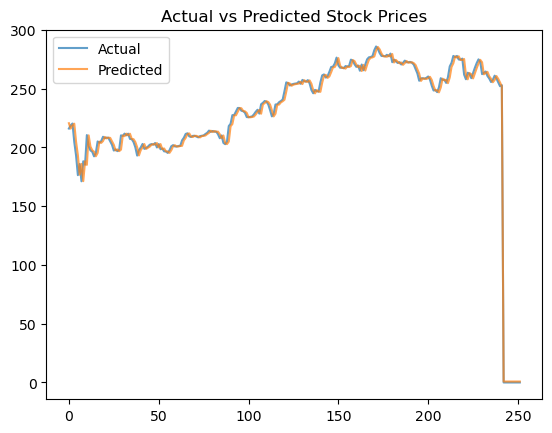

In [10]:
import matplotlib.pyplot as plt
plt.plot(y_test, label="Actual", alpha=0.7)
plt.plot(Y_pred_linear, label="Predicted", alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()

Using DecisionTree

In [11]:
dec_tree = DecisionTreeRegressor(random_state = 0)
dec_tree.fit(X_train, y_train)

Y_pred_tree = dec_tree.predict(X_test)
mse_tree_test = mean_squared_error(Y_pred_tree, y_test)

#Y_predTrain_tree = dec_tree.predict(X_test)
#mse_tree_train = mean_squared_error(Y_predTrain_tree, y_train)

#print(f"MSE of Decision Tree (train): {mse_tree_train}")
print(f"MSE of Decision Tree (test): {mse_tree_test}")

MSE of Decision Tree (test): 713.8221985944882


Random Forest and MLP Regressor

In [12]:
forest = RandomForestRegressor(n_estimators = 100, random_state = 0, n_jobs = 1)
forest.fit(X_train, y_train)

mlp = MLPRegressor(random_state=42, max_iter=3000).fit(X_train, y_train)

In [13]:
#random forest predictions on training data
Y_predTrain_forest = forest.predict(X_train)
mse_forest_train = mean_squared_error(y_train, Y_predTrain_forest)

#random forest predictions on test data
Y_pred_forest = forest.predict(X_test)
mse_forest_test = mean_squared_error(y_test, Y_pred_forest)

print(f"MSE of Random Forest (train): {mse_forest_train}")
print(f"MSE of Random Forest (test): {mse_forest_test}") #why is this so high? See if standard scaler has any use here

MSE of Random Forest (train): 1.562848854417298
MSE of Random Forest (test): 691.6020890087048


In [14]:
#MLP predictions on training data
Y_predTrain_mlp = mlp.predict(X_train)
mse_mlp_train = mean_squared_error(y_train, Y_predTrain_mlp)

#MLP predictions on testing data
Y_pred_mlp = mlp.predict(X_test)
mse_mlp_test = mean_squared_error(y_test, Y_pred_mlp)

print(f"MSE of MLP Regressor (train): {mse_mlp_train}")
print(f"MSE of MLP Regressor (test): {mse_mlp_test}")

MSE of MLP Regressor (train): 13.015523232651253
MSE of MLP Regressor (test): 31.54339660016249


K-Nearest Neighbors

In [15]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
#Training accuracy
Y_predTrain_knn = knn.predict(X_train)
mse_knn_train = mean_squared_error(y_train, Y_predTrain_knn)
print(f"MSE of KNN (train): {mse_knn_train}")

#test accuracy
Y_pred_knn = knn.predict(X_test)
mse_knn_test = mean_squared_error(y_test, Y_pred_knn)
print(f"MSE Test Accuracy: {mse_knn_test}")

MSE of KNN (train): 6.1126406262443025
MSE Test Accuracy: 689.4882818462372


Lasso & Ridge Models

In [17]:
from sklearn.linear_model import Lasso
lasso_model = sklearn.linear_model.Lasso(alpha=0.1, random_state=0)
lasso_model.fit(X_train, y_train)
y_pred_lasso_train = lasso_model.predict(X_train)
y_pred_lasso_test = lasso_model.predict(X_test)
print(f"Training MSE: {mean_squared_error(y_train, y_pred_lasso_train)}")
print(f"Testing MSE: {mean_squared_error(y_test, y_pred_lasso_test)}")

Training MSE: 8.701204369712041
Testing MSE: 19.16391747589428


In [18]:
from sklearn.linear_model import Ridge
ridge_model = sklearn.linear_model.Ridge(alpha=1.0, random_state=0)
ridge_model.fit(X_train, y_train)
y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge_test = ridge_model.predict(X_test)
print(f"Training MSE: {mean_squared_error(y_train, y_pred_ridge_train)}")
print(f"Testing MSE: {mean_squared_error(y_test, y_pred_ridge_test)}")

Training MSE: 8.701128416905231
Testing MSE: 19.182598298081228


Defining simple function for simulating:

In [19]:
#using best model (linear model) to predict and simulate buying and selling
def simpleSimulateBuySell(predictions, amount, interval, stocks, days):
  for i in range(days):
    if (predictions[i+1] < Y[i] and stocks > 0):
      stocks -= interval
      amount += Y[i] * interval
    elif (predictions[i + 1] > Y[i] and amount > Y[i]):
      stocks += interval
      amount -= Y[i] * interval

  amount += Y[i] * stocks
  print(f"Investing in {name}, Final Amount: ${str(amount.round(2))}")

#def realisticSimulateBuySell():

In [20]:
predictions = lin_regr.predict(X) #using linear model in this case
amount = 50000
stocks = 0

simpleSimulateBuySell(predictions, amount, 3, stocks, 1200)

import math
print(f"If we had just held the {name} stock from the beginning to the end, we would have made ${str((math.floor(50000/Y[0]) * Y[1200] - Y[0]).round(2))}.")

Investing in AAPL, Final Amount: $85906.59
If we had just held the AAPL stock from the beginning to the end, we would have made $115879.59.


Simulating with all 7 models:

In [21]:
results = []
for predictor in [lin_regr, forest, mlp, knn, dec_tree, ridge_model, lasso_model]:
    predictions = predictor.predict(X)
    amount = initial = 50000
    stocks = 0
    #If price is lower, buy

    for i in range(1200):
        if (predictions[i+1] < Y[i] and stocks>0):
            stocks -= 1
            amount += Y[i]
        elif (predictions[i + 1] > Y[i] and amount > Y[i]):
            stocks += 1
            amount -= Y[i]
    amount += Y[i] * stocks
    stocks = 0

    results.append({
        "Model": type(predictor).__name__,
        "Final Amount": round(amount, 2)
    })
    #print(amount, stocks)

df = pd.DataFrame(results)

In [22]:
df

,Model,Final Amount
0,LinearRegression,81599.38
1,RandomForestRegressor,64155.62
2,MLPRegressor,52243.57
3,KNeighborsRegressor,62693.40
4,DecisionTreeRegressor,61303.95
5,Ridge,81735.61
6,Lasso,81419.75


### Training vs. Test vs. Validation

- Validation set is important because you want to separate testing for the model and for post-training.
- We use validation set (unseen data) to define base parameters & hyperparameter tuning
- With validation, your model will be less susceptible to overfitting (biased estimate of real world performance of the model)

**validation set simulates the testing set**

In [23]:
#If today is 10% higher, be more aggressive
def test_stock_market(stocks_to_buy=30, initial=50000):
    max_amt = 0
    for predictor in [lin_regr, forest, mlp, knn, dec_tree]:
        predictions = predictor.predict(X)
        amount = initial
        stocks = 0

        for i in range(1200):
            if (predictions[i+1] < Y[i] and stocks>0):
                amt = min(stocks, stocks_to_buy)
                stocks -= amt
                amount += amt*Y[i]
            elif (predictions[i + 1] > Y[i] and amount > Y[i]):
                amt_to_buy = min(amount//Y[i], stocks_to_buy)
                stocks += amt_to_buy
                amount -= amt_to_buy*Y[i]
        amount += Y[1200] * stocks
        stocks = 0
        max_amt = max(amount, max_amt)
    return max_amt
A = 0
#running tests (monte carlo simulation)
for i in range(0, 32):
    A = max(A, test_stock_market(i**2))
A

2332219.0351845524

In [24]:
import random
#Should be outperforming the baselines
def baseline_p(p=0.5):
    amount = 50000
    stocks = 0
    for i in range(1200):
        R = random.random()
        if R < p:
            buy=True
        else:
            buy = False
        if stocks==0:
            buy=True
        if amount < Y[i]:
            buy=False
        if buy:
            stocks += 1
            amount -= Y[i]
        else:
            stocks -= 1
            amount += Y[i]
    amount += Y[i] * stocks
    stocks = 0
    return amount

def test_stock_market(stocks_to_buy=30, initial=50000):
    '''Testing Comments'''
    max_amt = 0
    for predictor in [lin_regr, forest, mlp, knn, dec_tree]:
        predictions = predictor.predict(X)
        amount = initial
        stocks = 0

        for i in range(1200):
            if (predictions[i+1] < Y[i] and stocks>0):
                amt = min(stocks, stocks_to_buy)
                stocks -= amt
                amount += amt*Y[i]
            elif (predictions[i + 1] > Y[i] and amount > Y[i]):
                amt_to_buy = min(amount//Y[i], stocks_to_buy)
                stocks += amt_to_buy
                amount -= amt_to_buy*Y[i]
        amount += Y[i] * stocks
        stocks = 0
        max_amt = max(amount, max_amt)
    return max_amt

In [25]:
print("DISCLAIMER: To model the stock market and its randomness, the baseline will vary.")
print(f"Baseline: ${baseline_p().round(2)}")

DISCLAIMER: To model the stock market and its randomness, the baseline will vary.
Baseline: $52421.84


In [26]:
print(f"Best outcome: ${test_stock_market().round(2)}")

Best outcome: $165703.45


(1260, 3)


<ErrorbarContainer object of 3 artists>

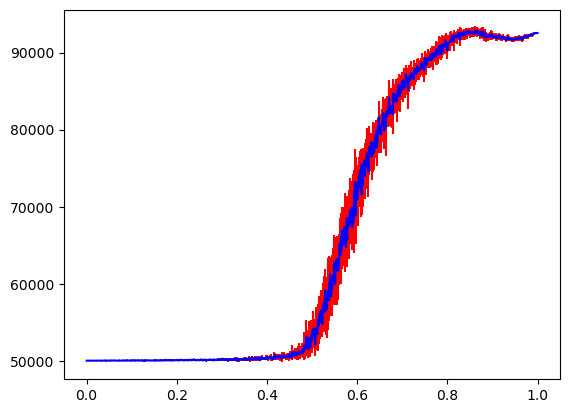

In [27]:
Z = 1001
p = np.linspace(0, 1, Z)
print(X.shape)
T = 9
money_made = np.zeros((Z, T))

for i,x in enumerate(p):
    for j in range(T):
        money_made[i][j] = baseline_p(x)
plt.errorbar(p, np.mean(money_made, axis=1), yerr=np.std(money_made, axis=1), ecolor='red', color='blue')

_________________________________________________________________________________

# Portfolio Upgrade: Multi-Feature ML + Walk-Forward CV + Multi-Ticker + Paper Trading

The earlier section is a good learning baseline (single ticker, simple lag features, single split).

This section upgrades it into a portfolio-ready workflow:
- **Richer features**: OHLCV + RSI + MACD + volatility + rolling volume features (optional sentiment hook)
- **Walk-forward validation**: evaluate strictly out-of-sample through time (no single train/test split)
- **Multiple tickers**: compare performance and analyze cross-stock return correlations
- **Deployment**: minimal Alpaca paper-trading loop (free) using environment variables


In [28]:
import os
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


## Feature engineering (OHLCV + RSI + MACD + rolling stats)

We predict **next-day return** (regression). That makes evaluation and cross-ticker comparisons cleaner than predicting raw price levels.

You can swap the model later (XGBoost, LightGBM, LSTM, transformers) without changing the data plumbing.


In [29]:
def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return 100 - (100 / (1 + rs))


def _macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9) -> Tuple[pd.Series, pd.Series, pd.Series]:
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist


def add_features(price_df: pd.DataFrame, sentiment_daily: Optional[pd.Series] = None) -> Tuple[pd.DataFrame, List[str]]:
    """Return feature DataFrame indexed by date.

    `price_df` must contain: Open, High, Low, Close, Volume.
    `sentiment_daily` (optional) should be indexed by date (same timezone) with a numeric sentiment score.
    """
    df = price_df.copy()
    df = df.sort_index()

    # Returns / volatility
    df["ret_1d"] = df["Close"].pct_change()
    df["log_ret_1d"] = np.log(df["Close"]).diff()
    df["vol_20d"] = df["ret_1d"].rolling(20).std()

    # Volume features
    df["vol_chg_1d"] = df["Volume"].pct_change()
    df["vol_z_20d"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / df["Volume"].rolling(20).std()

    # Trend/momentum indicators
    df["sma_10"] = df["Close"].rolling(10).mean()
    df["sma_20"] = df["Close"].rolling(20).mean()
    df["ema_10"] = df["Close"].ewm(span=10, adjust=False).mean()

    df["rsi_14"] = _rsi(df["Close"], period=14)
    macd, macd_signal, macd_hist = _macd(df["Close"], fast=12, slow=26, signal=9)
    df["macd"] = macd
    df["macd_signal"] = macd_signal
    df["macd_hist"] = macd_hist

    # Price-based lags (keep small; easy to expand)
    for lag in (1, 2, 3, 5):
        df[f"ret_lag_{lag}"] = df["ret_1d"].shift(lag)
        df[f"vol_chg_lag_{lag}"] = df["vol_chg_1d"].shift(lag)

    # Optional sentiment (hook)
    if sentiment_daily is None:
        df["sentiment"] = 0.0
    else:
        df["sentiment"] = sentiment_daily.reindex(df.index).astype(float).fillna(0.0)

    # Predict next-day return
    df["target_next_ret_1d"] = df["ret_1d"].shift(-1)

    # Drop rows with NaNs from rolling windows / shifts
    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "ret_1d",
        "log_ret_1d",
        "vol_20d",
        "vol_chg_1d",
        "vol_z_20d",
        "sma_10",
        "sma_20",
        "ema_10",
        "rsi_14",
        "macd",
        "macd_signal",
        "macd_hist",
        "sentiment",
        "ret_lag_1",
        "ret_lag_2",
        "ret_lag_3",
        "ret_lag_5",
        "vol_chg_lag_1",
        "vol_chg_lag_2",
        "vol_chg_lag_3",
        "vol_chg_lag_5",
    ]

    df = df.dropna(subset=feature_cols + ["target_next_ret_1d"]) 
    return df, feature_cols


In [30]:
def fetch_ohlcv(ticker: str, period: str = "5y", interval: str = "1d") -> pd.DataFrame:
    df = yf.Ticker(ticker).history(period=period, interval=interval)
    # Keep OHLCV only
    keep = ["Open", "High", "Low", "Close", "Volume"]
    df = df[keep].dropna()
    # yfinance sometimes returns timezone-aware indices; normalize to date for joining.
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df


demo_ticker = "AAPL"
demo_prices = fetch_ohlcv(demo_ticker, period="5y")
demo_feat_df, demo_feature_cols = add_features(demo_prices)
demo_feat_df.head()


,Open,High,Low,Close,Volume,ret_1d,log_ret_1d,vol_20d,vol_chg_1d,vol_z_20d,sma_10,sma_20,ema_10,rsi_14,macd,macd_signal,macd_hist,ret_lag_1,vol_chg_lag_1,ret_lag_2,vol_chg_lag_2,ret_lag_3,vol_chg_lag_3,ret_lag_5,vol_chg_lag_5,sentiment,target_next_ret_1d
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-04-20,131.508910,132.005643,128.382377,129.648575,94812300,-0.012830,-0.012913,0.014315,0.005815,0.409591,129.109933,124.113824,128.520233,56.339693,2.928601,2.227662,0.700939,0.005069,0.110004,-0.002528,-0.049523,0.018708,0.024355,0.024306,-0.001679,0.0,0.002930
2021-04-21,128.918027,130.271880,127.885595,130.028381,68847100,0.002930,0.002925,0.014092,-0.273859,-1.939405,129.655367,124.647572,128.794442,57.209495,2.881684,2.358467,0.523218,-0.012830,0.005815,0.005069,0.110004,-0.002528,-0.049523,-0.017853,-0.044307,0.0,-0.011685
2021-04-22,129.580389,130.661525,127.992786,128.509003,84566500,-0.011685,-0.011754,0.013443,0.228323,-0.446884,129.809261,125.224665,128.742544,52.687508,2.690882,2.424950,0.265933,0.002930,-0.273859,-0.012830,0.005815,0.005069,0.110004,0.018708,0.024355,0.0,0.018038
2021-04-23,128.723223,131.606241,128.723223,130.827057,78657500,0.018038,0.017877,0.013763,-0.069874,-0.902232,129.937826,125.893312,129.121546,58.125660,2.695644,2.479089,0.216556,-0.011685,0.228323,0.002930,-0.273859,-0.012830,0.005815,-0.002528,-0.049523,0.0,0.002978
2021-04-26,131.323800,131.547814,130.086821,131.216660,66905100,0.002978,0.002974,0.013774,-0.149412,-1.722237,130.276772,126.551245,129.502476,58.979082,2.699735,2.523218,0.176517,0.018038,-0.069874,-0.011685,0.228323,0.002930,-0.273859,0.005069,0.110004,0.0,-0.002449


## Walk-forward cross-validation (time-series safe)

Instead of one fixed split, we do **expanding-window** evaluation:
- Train on an early window
- Test on the next contiguous window
- Repeat forward through time

This is much closer to how a model behaves in live trading.


In [31]:
@dataclass
class WalkForwardResult:
    fold_metrics: pd.DataFrame
    oos_pred: pd.Series
    oos_true: pd.Series


def walk_forward_cv(
    X: pd.DataFrame,
    y: pd.Series,
    model: Pipeline,
    n_splits: int = 6,
) -> WalkForwardResult:
    """Walk-forward CV with strictly forward-looking splits."""
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_rows = []
    oos_pred = pd.Series(index=y.index, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = pd.Series(model.predict(X_test), index=y_test.index, dtype=float)
        oos_pred.loc[pred.index] = pred

        mse = mean_squared_error(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)
        dir_acc = (np.sign(pred) == np.sign(y_test)).mean()

        fold_rows.append(
            {
                "fold": fold,
                "train_start": X_train.index.min(),
                "train_end": X_train.index.max(),
                "test_start": X_test.index.min(),
                "test_end": X_test.index.max(),
                "mse": mse,
                "mae": mae,
                "r2": r2,
                "directional_accuracy": dir_acc,
            }
        )

    fold_metrics = pd.DataFrame(fold_rows)
    oos_pred = oos_pred.dropna()
    oos_true = y.reindex(oos_pred.index)
    return WalkForwardResult(fold_metrics=fold_metrics, oos_pred=oos_pred, oos_true=oos_true)


def backtest_long_cash(
    realized_next_ret: pd.Series,
    predicted_next_ret: pd.Series,
    fee_bps: float = 1.0,
) -> pd.Series:
    """Simple long/cash strategy.

    - Take a long position (1x) if predicted next-day return > 0, else go to cash.
    - Apply a transaction fee when changing position.
    """
    realized_next_ret = realized_next_ret.astype(float)
    predicted_next_ret = predicted_next_ret.reindex(realized_next_ret.index).astype(float)
    signal = (predicted_next_ret > 0).astype(int)
    position = signal.shift(1).fillna(0).astype(int)  # decide using yesterday's prediction
    pos_change = position.diff().abs().fillna(position.abs())
    fee = (fee_bps / 10_000.0) * pos_change
    strat_ret = position * realized_next_ret - fee
    equity = (1 + strat_ret).cumprod()
    return equity


# Demo: a simple model (Ridge) with scaling
demo_X = demo_feat_df[demo_feature_cols]
demo_y = demo_feat_df["target_next_ret_1d"]

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=0)),
])

wf = walk_forward_cv(demo_X, demo_y, model=ridge_model, n_splits=6)
wf.fold_metrics


,fold,train_start,train_end,test_start,test_end,mse,mae,r2,directional_accuracy
0,1,2021-04-20,2021-12-31,2022-01-03,2022-09-14,0.000582,0.018604,-0.271382,0.465909
1,2,2021-04-20,2022-09-14,2022-09-15,2023-05-26,0.000404,0.015046,-0.063886,0.460227
2,3,2021-04-20,2023-05-26,2023-05-30,2024-02-08,0.000143,0.009087,-0.012409,0.539773
3,4,2021-04-20,2024-02-08,2024-02-09,2024-10-21,0.000287,0.012873,-0.232691,0.420455
4,5,2021-04-20,2024-10-21,2024-10-22,2025-07-08,0.000496,0.014339,-0.002305,0.517045
5,6,2021-04-20,2025-07-08,2025-07-09,2026-03-19,0.000218,0.010457,-0.067706,0.460227


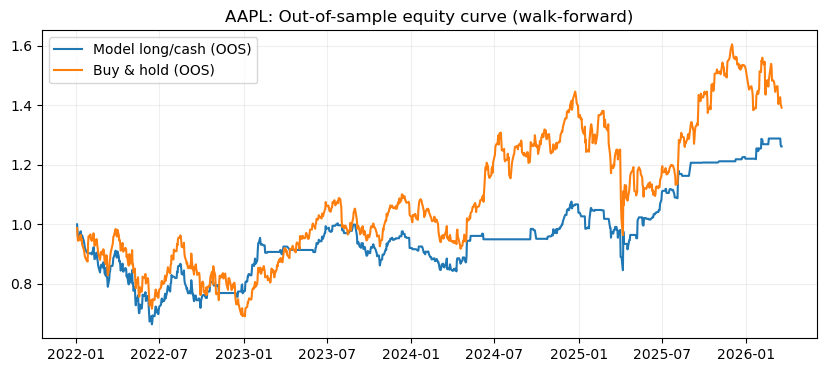

In [32]:
oos_equity = backtest_long_cash(wf.oos_true, wf.oos_pred, fee_bps=1.0)
buy_hold_equity = (1 + wf.oos_true).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(oos_equity.index, oos_equity.values, label="Model long/cash (OOS)")
plt.plot(buy_hold_equity.index, buy_hold_equity.values, label="Buy & hold (OOS)")
plt.title(f"{demo_ticker}: Out-of-sample equity curve (walk-forward)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


## Multi-ticker evaluation + cross-stock correlations

This runs the same pipeline across a basket of tickers.

Notes:
- The correlation matrix uses **daily returns**.
- The backtest uses only the walk-forward **out-of-sample** prediction stream.


In [33]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "TSLA"]

# Model options
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=0)),
])

rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=1)),
])

chosen_model = ridge_model

prices_by_ticker: Dict[str, pd.DataFrame] = {}
results_rows = []

for t in tickers:
    prices = fetch_ohlcv(t, period="5y")
    prices_by_ticker[t] = prices

    feat_df, feature_cols = add_features(prices)
    X = feat_df[feature_cols]
    y = feat_df["target_next_ret_1d"]

    wf = walk_forward_cv(X, y, model=chosen_model, n_splits=6)
    equity = backtest_long_cash(wf.oos_true, wf.oos_pred, fee_bps=1.0)
    buy_hold = (1 + wf.oos_true).cumprod()

    results_rows.append(
        {
            "ticker": t,
            "oos_mse_mean": wf.fold_metrics["mse"].mean(),
            "oos_dir_acc_mean": wf.fold_metrics["directional_accuracy"].mean(),
            "strategy_total_return": float(equity.iloc[-1] - 1),
            "buyhold_total_return": float(buy_hold.iloc[-1] - 1),
        }
    )

results_df = pd.DataFrame(results_rows).sort_values("strategy_total_return", ascending=False)
results_df


,ticker,oos_mse_mean,oos_dir_acc_mean,strategy_total_return,buyhold_total_return
4,NVDA,0.001291,0.509470,2.091298,4.744958
2,GOOGL,0.000449,0.470644,0.749314,1.093142
1,MSFT,0.000312,0.511364,0.405503,0.181672
0,AAPL,0.000355,0.477273,0.261593,0.392391
5,TSLA,0.001654,0.510417,-0.188008,-0.079931
3,AMZN,0.000866,0.494318,-0.254700,0.205191


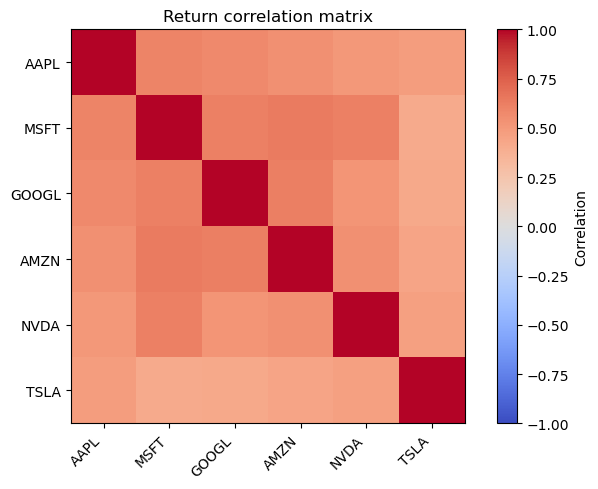

,AAPL,MSFT,GOOGL,AMZN,NVDA,TSLA
AAPL,1.000000,0.600537,0.573171,0.546283,0.506850,0.480180
MSFT,0.600537,1.000000,0.610061,0.635136,0.612587,0.410992
GOOGL,0.573171,0.610061,1.000000,0.617399,0.521025,0.414087
AMZN,0.546283,0.635136,0.617399,1.000000,0.544921,0.440053
NVDA,0.506850,0.612587,0.521025,0.544921,1.000000,0.464897
TSLA,0.480180,0.410992,0.414087,0.440053,0.464897,1.000000


In [34]:
# Cross-stock correlation (daily returns)
close_prices = pd.concat({t: df["Close"] for t, df in prices_by_ticker.items()}, axis=1).dropna()
ret = close_prices.pct_change().dropna()
corr = ret.corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
plt.title("Return correlation matrix")
plt.tight_layout()
plt.show()

corr


## Optional: sentiment feature hook

Historical sentiment usually requires a separate data source.

A simple free option is **Alpha Vantage News Sentiment** (requires a free API key). This cell shows a minimal fetch + daily aggregation pattern.

If you don’t want sentiment, you can ignore this and keep `sentiment=0`.


In [35]:
def fetch_alpha_vantage_daily_sentiment(
    api_key: str,
    ticker: str,
    limit: int = 1000,
) -> pd.Series:
    """Fetch and aggregate Alpha Vantage news sentiment to a daily series.

    Requires: `pip install requests`
    Docs: https://www.alphavantage.co/documentation/#news-sentiment
    """
    import requests

    url = "https://www.alphavantage.co/query"
    params = {
        "function": "NEWS_SENTIMENT",
        "tickers": ticker,
        "limit": limit,
        "apikey": api_key,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()
    feed = payload.get("feed", [])

    # Aggregate ticker_sentiment_score (or overall sentiment) by date.
    rows = []
    for item in feed:
        # time_published example: 20240216T123000
        tstamp = item.get("time_published")
        if not tstamp:
            continue
        date = pd.to_datetime(tstamp, format="%Y%m%dT%H%M%S", errors="coerce").normalize()
        if pd.isna(date):
            continue

        score = None
        for ts in item.get("ticker_sentiment", []):
            if ts.get("ticker") == ticker:
                try:
                    score = float(ts.get("ticker_sentiment_score"))
                except Exception:
                    score = None
                break

        if score is None:
            continue
        rows.append({"date": date, "score": score})

    if not rows:
        return pd.Series(dtype=float)

    daily = pd.DataFrame(rows).groupby("date")["score"].mean().sort_index()
    return daily


# Example usage (uncomment when you have a key):
# av_key = os.environ["ALPHAVANTAGE_API_KEY"]
# daily_sent = fetch_alpha_vantage_daily_sentiment(av_key, "AAPL")
# prices = fetch_ohlcv("AAPL", period="5y")
# feat_df, feature_cols = add_features(prices, sentiment_daily=daily_sent)


## Deploy: Alpaca paper trading (free)

This is a minimal, notebook-friendly deployment sketch:
- Train a model on historical data
- Save it with `joblib`
- Run a loop that periodically:
  - Pulls latest bars
  - Builds the same feature row
  - Predicts next-day return
  - Submits a paper order via Alpaca

You’ll need (paper trading):
- `ALPACA_API_KEY_ID`
- `ALPACA_API_SECRET_KEY`

Install: `pip install alpaca-py joblib`


In [36]:
def train_and_persist_model(ticker: str, out_path: str = "model.joblib"):
    import joblib

    prices = fetch_ohlcv(ticker, period="5y")
    feat_df, feature_cols = add_features(prices)
    X = feat_df[feature_cols]
    y = feat_df["target_next_ret_1d"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=0)),
    ])
    model.fit(X, y)

    joblib.dump({"model": model, "feature_cols": feature_cols}, out_path)
    return out_path


def alpaca_paper_trade_once(ticker: str, model_path: str, qty: int = 1, threshold: float = 0.0):
    """One-shot decision + order.

    This uses the *latest available daily bar* and submits a market order.
    For a real deployment you would:
    - schedule at a fixed time
    - manage positions/risk (max exposure, stops)
    - use Alpaca market data clients (or a dedicated data vendor)
    """
    import joblib

    bundle = joblib.load(model_path)
    model = bundle["model"]
    feature_cols = bundle["feature_cols"]

    # Latest data for feature row (yfinance is OK for a demo; use Alpaca data in production)
    prices = fetch_ohlcv(ticker, period="6mo")
    feat_df, _ = add_features(prices)
    latest_X = feat_df[feature_cols].iloc[[-1]]
    pred_next_ret = float(model.predict(latest_X)[0])
    print(f"Predicted next-day return for {ticker}: {pred_next_ret:.5f}")

    side = "buy" if pred_next_ret > threshold else "sell"
    print(f"Paper order decision: {side} {qty} shares")

    # Alpaca order submit
    from alpaca.trading.client import TradingClient
    from alpaca.trading.enums import OrderSide, TimeInForce
    from alpaca.trading.requests import MarketOrderRequest

    key = os.environ["ALPACA_API_KEY_ID"]
    secret = os.environ["ALPACA_API_SECRET_KEY"]
    client = TradingClient(key, secret, paper=True)

    order = MarketOrderRequest(
        symbol=ticker,
        qty=qty,
        side=OrderSide.BUY if side == "buy" else OrderSide.SELL,
        time_in_force=TimeInForce.DAY,
    )
    submitted = client.submit_order(order)
    return submitted


# Example usage:
# model_path = train_and_persist_model("AAPL", out_path="ridge_AAPL.joblib")
# alpaca_paper_trade_once("AAPL", model_path=model_path, qty=1, threshold=0.0)
